/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test accuracy without strong regularization: 0.911

Feature weights (coefficients) without strong regularization:
Class 'setosa':
  sepal length (cm): -1.077
  sepal width (cm): 0.955
  petal length (cm): -1.700
  petal width (cm): -1.603
Class 'versicolor':
  sepal length (cm): 0.473
  sepal width (cm): -0.447
  petal length (cm): -0.116
  petal width (cm): -0.793
Class 'virginica':
  sepal length (cm): 0.604
  sepal width (cm): -0.507
  petal length (cm): 1.816
  petal width (cm): 2.396

Test accuracy with stronger regularization (C=0.1): 0.844

Feature weights (coefficients) with stronger regularization (C=0.1):
Class 'setosa':
  sepal length (cm): -0.497
  sepal width (cm): 0.442
  petal length (cm): -0.701
  petal width (cm): -0.656
Class 'versicolor':
  sepal length (cm): 0.110
  sepal width (cm): -0.466
  petal length (cm): 0.086
  petal width (cm): -0.164
Class 'virginica':
  sepal length (cm): 0.387
  sepal width (cm): 0.024
  petal length (cm): 0.615
  petal width (cm): 0.820

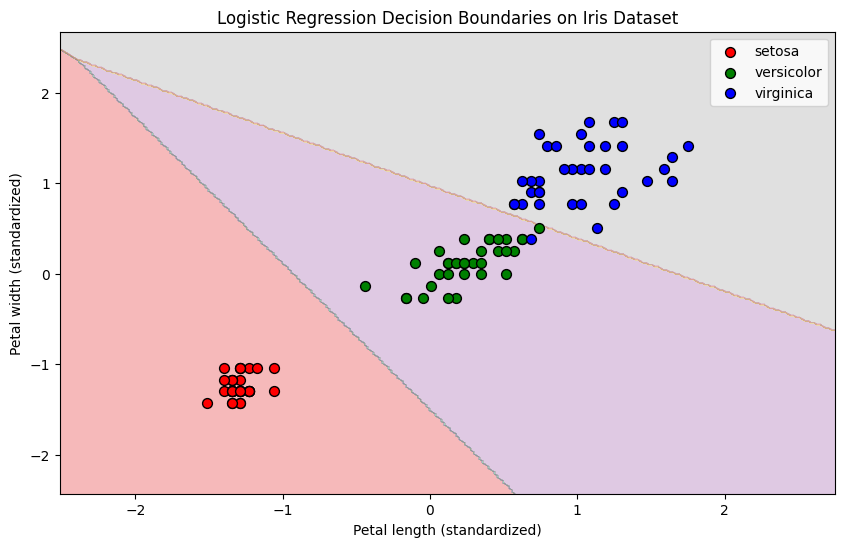

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression without explicit regularization (default L2, C=1)
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
clf.fit(X_train_scaled, y_train)

print(f"Test accuracy without strong regularization: {clf.score(X_test_scaled, y_test):.3f}")

# Display feature weights per class
print("\nFeature weights (coefficients) without strong regularization:")
for i, class_name in enumerate(target_names):
    print(f"Class '{class_name}':")
    for feature, weight in zip(feature_names, clf.coef_[i]):
        print(f"  {feature}: {weight:.3f}")

# Train logistic regression with stronger regularization (lower C)
clf_reg = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=200, C=0.1
)
clf_reg.fit(X_train_scaled, y_train)

print(f"\nTest accuracy with stronger regularization (C=0.1): {clf_reg.score(X_test_scaled, y_test):.3f}")

print("\nFeature weights (coefficients) with stronger regularization (C=0.1):")
for i, class_name in enumerate(target_names):
    print(f"Class '{class_name}':")
    for feature, weight in zip(feature_names, clf_reg.coef_[i]):
        print(f"  {feature}: {weight:.3f}")

# Visualize decision boundaries using two features: petal length and petal width
X_2d = X[:, 2:4]  # petal length and petal width

# Split and scale 2D data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train logistic regression on 2D data
clf_2d = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
clf_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict on mesh grid
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries and training points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

colors = ['red', 'green', 'blue']
for i, color, label in zip(range(len(target_names)), colors, target_names):
    plt.scatter(
        X_train_2d_scaled[y_train_2d == i, 0],
        X_train_2d_scaled[y_train_2d == i, 1],
        c=color, label=label, edgecolor='k', s=50
    )

plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.title('Logistic Regression Decision Boundaries on Iris Dataset')
plt.legend()
plt.show()
